# 05. Evaluation

This notebook evaluates the performance of both the **Retrieval** and **Reuse/Prediction** components of the Case-Based Reasoning (CBR) system.

### Evaluation Metrics:
1. **Classifier Performance (Prediction)**:
   - Accuracy
   - Precision
   - Recall
   - F1-Score
   - Confusion Matrix (Visualization & Analysis)
2. **Retrieval Performance**:
   - Mean Reciprocal Rank (MRR)
   - Precision at $K$ ($P@1$, $P@3$, $P@5$)
   - Recall at $K$ ($R@1$, $R@3$, $R@5$)

### Output Saved Files:
- `eval/prediction_metrics.csv`: Tabular metrics for classification prediction.
- `eval/retrieval_metrics.csv`: Tabular metrics for retrieval effectiveness.

In [8]:
import os
import re
import pickle
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, classification_report
)
from sklearn.metrics.pairwise import cosine_similarity

# Import Sastrawi components for query preprocessing
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

# Matplotlib inline plotting
%matplotlib inline
sns.set_theme(style="whitegrid")

In [9]:
# Define paths and load assets
EVAL_DIR = Path("../eval")
EVAL_DIR.mkdir(parents=True, exist_ok=True)

CASES_CSV_PATH = Path("../data/processed/cases.csv")
VECTORIZER_PATH = Path("../models/tfidf_vectorizer.pkl")
SVM_MODEL_PATH = Path("../models/svm_model.pkl")

df_cases = pd.read_csv(CASES_CSV_PATH)
with open(VECTORIZER_PATH, 'rb') as f:
    vectorizer = pickle.load(f)
with open(SVM_MODEL_PATH, 'rb') as f:
    svm_model = pickle.load(f)

# Reconstruct case texts
RAW_TEXT_DIR = Path("../data/raw_text")
texts = []
for _, row in df_cases.iterrows():
    case_id = row['Case ID']
    txt_file = RAW_TEXT_DIR / f"{case_id}.txt"
    if txt_file.exists():
        with open(txt_file, 'r', encoding='utf-8') as f:
            texts.append(f.read())
    else:
        combined_meta = f"{row['Ringkasan fakta']} {row['Amar putusan']} {row['Pasal']}"
        texts.append(combined_meta)
df_cases['cleaned_text'] = texts

# Fit/Transform full matrix
tfidf_matrix = vectorizer.transform(df_cases['cleaned_text'])
print("Assets loaded successfully.")

Assets loaded successfully.


In [10]:
# Section 1: Classification & Reuse Outcome Prediction Evaluation

# Verdict mappings
def label_verdict(row):
    amar = str(row['Amar putusan']).lower()
    if "bebas" in amar or "lepas" in amar or "onslag" in amar or "tidak terbukti" in amar:
        return 0 # Bebas/Lepas
    return 1 # Bersalah

df_cases['Label'] = df_cases.apply(label_verdict, axis=1)

# Recreate the train/test split (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    df_cases['cleaned_text'], 
    df_cases['Label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df_cases['Label']
)

# Transform test set
X_test_tfidf = vectorizer.transform(X_test)

# Generate Predictions
y_pred = svm_model.predict(X_test_tfidf)

# Compute prediction metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

pred_metrics = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Value": [accuracy, precision, recall, f1]
}
df_pred_metrics = pd.DataFrame(pred_metrics)

# Save prediction metrics
pred_csv_path = EVAL_DIR / "prediction_metrics.csv"
df_pred_metrics.to_csv(pred_csv_path, index=False)
print(f"Saved prediction metrics to {pred_csv_path.resolve()}")
display(df_pred_metrics)

Saved prediction metrics to D:\Lectures\Semester 8\Penalaran\CBR-Pemalsuan-Surat\eval\prediction_metrics.csv


,Metric,Value
0,Accuracy,0.833333
1,Precision,0.833333
2,Recall,1.000000
3,F1-Score,0.909091


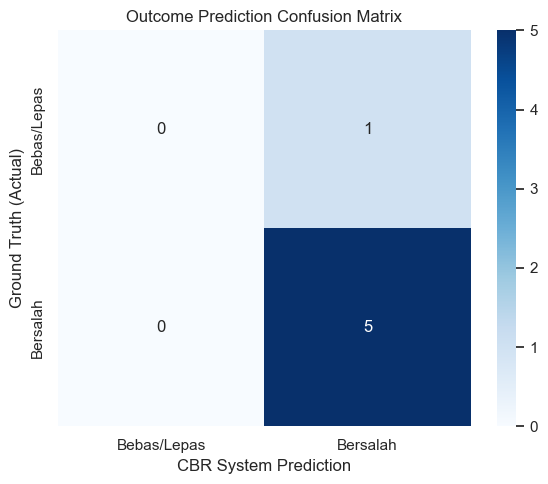

In [11]:
# Generate & Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt="d", 
    cmap="Blues", 
    xticklabels=["Bebas/Lepas", "Bersalah"], 
    yticklabels=["Bebas/Lepas", "Bersalah"]
)
plt.ylabel('Ground Truth (Actual)')
plt.xlabel('CBR System Prediction')
plt.title('Outcome Prediction Confusion Matrix')
plt.tight_layout()
plt.savefig(EVAL_DIR / "confusion_matrix.png")
plt.show()

C:\Users\DEYSEN\AppData\Local\Temp\ipykernel_4056\2982167121.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Metric", y="Value", data=df_pred_metrics, palette="Blues_d")


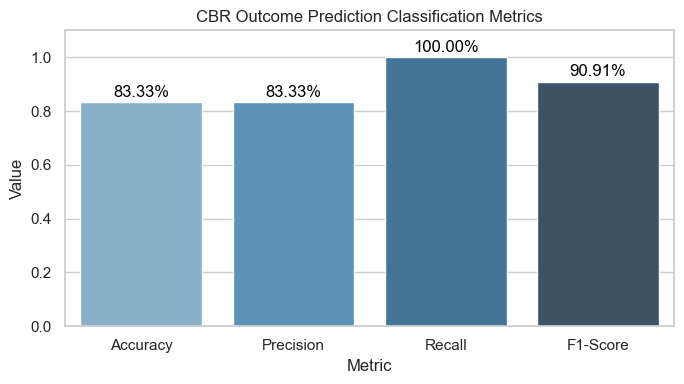

In [12]:
# Generate & Plot Metrics Bar Chart
plt.figure(figsize=(7, 4))
sns.barplot(x="Metric", y="Value", data=df_pred_metrics, palette="Blues_d")
plt.ylim(0, 1.1)
plt.title("CBR Outcome Prediction Classification Metrics")
for index, row in df_pred_metrics.iterrows():
    plt.text(index, row['Value'] + 0.02, f"{row['Value']:.2%}", color='black', ha="center")
plt.tight_layout()
plt.savefig(EVAL_DIR / "prediction_metrics_chart.png")
plt.show()

In [13]:
# Section 2: Retrieval Engine Evaluation

# Setup Sastrawi components for query cleaning inside evaluation retrieval
stop_factory = StopWordRemoverFactory()
indonesian_stopwords = set(stop_factory.get_stop_words())
indonesian_stopwords.update({'dan', 'yang', 'untuk', 'dengan', 'pada', 'atau', 'adalah', 'bahwa'})
stem_factory = StemmerFactory()
stemmer = stem_factory.create_stemmer()

def preprocess_query(query: str) -> str:
    query_clean = re.sub(r'[^a-zA-Z\s]', ' ', query.lower())
    tokens = query_clean.split()
    filtered_tokens = [w for w in tokens if w not in indonesian_stopwords]
    stemmed = [stemmer.stem(w) for w in filtered_tokens]
    return ' '.join([w for w in stemmed if len(w) > 1])

def retrieve(query: str, k: int = 5) -> pd.DataFrame:
    cleaned_query = preprocess_query(query)
    query_vector = vectorizer.transform([cleaned_query])
    similarities = cosine_similarity(query_vector, tfidf_matrix).flatten()
    df_res = df_cases.copy()
    df_res['Similarity Score'] = similarities
    return df_res.sort_values(by='Similarity Score', ascending=False).head(k)

# Define Ground Truth query-case relevance maps for validation
retrieval_tests = [
    {
        "query": "terdakwa dikson tuage melakukan pemalsuan bersama riki suharyanto suhartono",
        "ground_truth": "case001"
    },
    {
        "query": "slip gaji theo bulan juli 2021 yang dikeluarkan oleh pt in",
        "ground_truth": "case002"
    },
    {
        "query": "surat keterangan tidak sengketa tanggal 3 agustus 2022 jamotan lumban gaol",
        "ground_truth": "case003"
    },
    {
        "query": "suryadi bin abu bakar memalsukan surat tanda bukti pemindahan hak ganti rugi yusmaini",
        "ground_truth": "case004"
    },
    {
        "query": "terdakwa jacob abolladaka mengajukan banding terhadap putusan kupang nomor 56",
        "ground_truth": "case005"
    }
]

ranks = []
p_at_1, p_at_3, p_at_5 = [], [], []
r_at_1, r_at_3, r_at_5 = [], [], []

for test in retrieval_tests:
    query = test["query"]
    gt = test["ground_truth"]
    
    # Retrieve top 5
    retrieved = retrieve(query, k=5)
    retrieved_list = list(retrieved['Case ID'])
    
    # Find rank of ground truth (1-indexed)
    if gt in retrieved_list:
        rank = retrieved_list.index(gt) + 1
        ranks.append(rank)
    else:
        rank = 0
        ranks.append(0)
        
    # Precision at K
    p_at_1.append(1.0 if gt in retrieved_list[:1] else 0.0)
    p_at_3.append(1.0 / 3.0 if gt in retrieved_list[:3] else 0.0)
    p_at_5.append(1.0 / 5.0 if gt in retrieved_list[:5] else 0.0)
    
    # Recall at K
    r_at_1.append(1.0 if gt in retrieved_list[:1] else 0.0)
    r_at_3.append(1.0 if gt in retrieved_list[:3] else 0.0)
    r_at_5.append(1.0 if gt in retrieved_list[:5] else 0.0)

# Calculate Mean Reciprocal Rank (MRR)
mrr_list = [1.0 / r if r > 0 else 0.0 for r in ranks]
mrr = np.mean(mrr_list)

# Aggregate metrics
retrieval_metrics = {
    "Metric": [
        "Precision@1", "Precision@3", "Precision@5", 
        "Recall@1", "Recall@3", "Recall@5", 
        "Mean Reciprocal Rank (MRR)"
    ],
    "Value": [
        np.mean(p_at_1), np.mean(p_at_3), np.mean(p_at_5),
        np.mean(r_at_1), np.mean(r_at_3), np.mean(r_at_5),
        mrr
    ]
}
df_ret_metrics = pd.DataFrame(retrieval_metrics)

# Save retrieval metrics
ret_csv_path = EVAL_DIR / "retrieval_metrics.csv"
df_ret_metrics.to_csv(ret_csv_path, index=False)
print(f"Saved retrieval metrics to {ret_csv_path.resolve()}")
display(df_ret_metrics)

Saved retrieval metrics to D:\Lectures\Semester 8\Penalaran\CBR-Pemalsuan-Surat\eval\retrieval_metrics.csv


,Metric,Value
0,Precision@1,0.800000
1,Precision@3,0.333333
2,Precision@5,0.200000
3,Recall@1,0.800000
4,Recall@3,1.000000
5,Recall@5,1.000000
6,Mean Reciprocal Rank (MRR),0.866667


C:\Users\DEYSEN\AppData\Local\Temp\ipykernel_4056\3445364730.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Metric", y="Value", data=df_ret_metrics, palette="Blues_d")


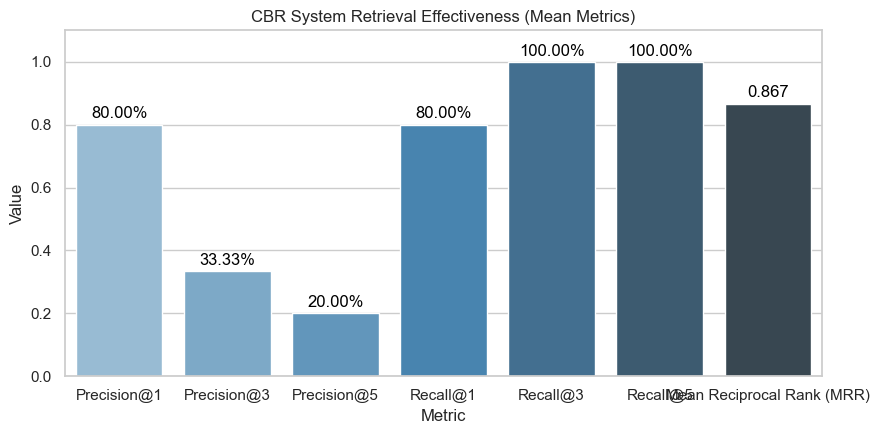

In [14]:
# Visualizing Retrieval Effectiveness
plt.figure(figsize=(9, 4.5))
sns.barplot(x="Metric", y="Value", data=df_ret_metrics, palette="Blues_d")
plt.ylim(0, 1.1)
plt.title("CBR System Retrieval Effectiveness (Mean Metrics)")
for index, row in df_ret_metrics.iterrows():
    plt.text(index, row['Value'] + 0.02, f"{row['Value']:.2%}" if "Rank" not in row['Metric'] else f"{row['Value']:.3f}", color='black', ha="center")
plt.tight_layout()
plt.savefig(EVAL_DIR / "retrieval_metrics_chart.png")
plt.show()